# HQNN Demo - Hybrid Quantum Neural Network

This notebook demonstrates the complete HQNN pipeline for CaF₂/CaF₂:Er spectral classification using Hybrid Quantum classical model

## Architecture
```
Input (3 features) → PreQuantumNN (3→3) → QuantumLayer (3 qubits) → PostQuantumNN (3→8→1) → Output
```

## Features Used
1. α (Absorption cm^-1)
2. κ (Extinction coeff)
3. Energy (eV)

In [1]:
# =====================================================
# Setup script to add the project root to the Python path
# =====================================================
import sys
from pathlib import Path

project_root = Path.cwd().parent.parent  # Go up 2 levels

# If running from a different directory, try to find it
if not (project_root / "qiskit_qml").exists():
    # Try current directory
    project_root = Path.cwd()
    while (
        not (project_root / "qiskit_qml").exists()
        and project_root != project_root.parent
    ):
        project_root = project_root.parent

if (project_root / "qiskit_qml").exists():
    sys.path.insert(0, str(project_root))
    print(f"✓ Added to Python path: {project_root}")
else:
    print("⚠️ Could not find project root. Please run from Q-UCSpec directory.")
    print(f"Current directory: {Path.cwd()}")

⚠️ Could not find project root. Please run from Q-UCSpec directory.
Current directory: /Users/ragunathchandrasekharan/Documents/Documents/Masters/Quantum Computing/qiskit-advocate/projects/QAMP/QUCSpec/code/refined/HQFr/Q-UCSpec-Ext/hqnn_ragu


In [2]:
# Setup
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from torch.utils.data import DataLoader, TensorDataset

# Set seed for reproducibility
from config import SEED, set_seed

set_seed(SEED)

# Force float64 for precision
torch.set_default_dtype(torch.float64)


print(f"PyTorch: {torch.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch: 2.5.1
NumPy: 1.26.4
Device: cpu


## 1. Data Loading & Visualization

In [3]:
from preprocessing import FEATURE_COLUMNS, load_and_preprocess

# Load data
X_train, X_val, X_test, y_train, y_val, y_test, transformer, pos_weight = (
    load_and_preprocess()
)

HQNN DATA PREPROCESSING

Dataset loaded:
  Train: 2016 samples
  Val:   432 samples
  Test:  433 samples

Features (3):
    1. κ (Extinction coeff)
    2. α (Absorption cm^-1)
    3. Energy (eV)

Class distribution (train): [ 904 1112]
Pos weight: 0.8129


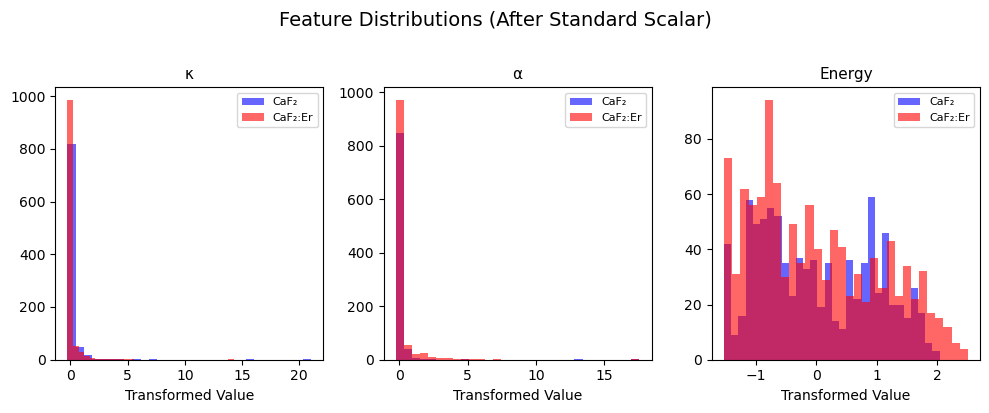

In [4]:
# Visualize feature distributions
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
axes = axes.flatten()

for i, (ax, name) in enumerate(zip(axes, FEATURE_COLUMNS, strict=False)):
    ax.hist(X_train[y_train == 0, i], bins=30, alpha=0.6, label="CaF₂", color="blue")
    ax.hist(X_train[y_train == 1, i], bins=30, alpha=0.6, label="CaF₂:Er", color="red")
    ax.set_title(name.split("(")[0].strip(), fontsize=11)
    ax.legend(fontsize=8)
    ax.set_xlabel("Transformed Value")

plt.suptitle("Feature Distributions (After Standard Scalar)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

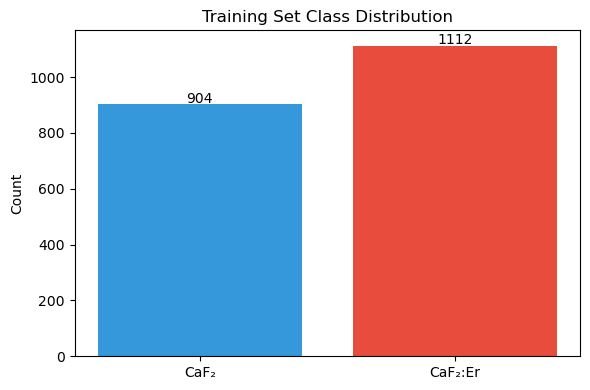

Class imbalance ratio: 0.813
Pos weight for loss: 0.8129


In [5]:
# Class distribution
fig, ax = plt.subplots(figsize=(6, 4))
labels = ["CaF₂", "CaF₂:Er"]
counts = [sum(y_train == 0), sum(y_train == 1)]
bars = ax.bar(labels, counts, color=["#3498db", "#e74c3c"])
ax.set_ylabel("Count")
ax.set_title("Training Set Class Distribution")
for bar, count in zip(bars, counts, strict=False):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 5, str(count), ha="center"
    )
plt.tight_layout()
plt.show()

print(f"Class imbalance ratio: {counts[0] / counts[1]:.3f}")
print(f"Pos weight for loss: {pos_weight:.4f}")

## 2. Model Architecture

In [6]:
from config import N_LAYERS, N_QUBITS, N_REPEATS
from shqnn_model import S_HQNN

# Initialize model
model = S_HQNN(n_qubits=N_QUBITS, n_layers=N_LAYERS, n_repeats=N_REPEATS)

✓ Quantum device: default.qubit (CPU)
✓ QuantumLayer initialized
    Qubits: 3
    IQP repeats: 1
    StronglyEntanglingLayers: 4 (unified)
    Entanglement ranges: [1, 1, 2, 2]
    Parameters: 36
    Feature scaling: sigmoid → [0, 2π]
PreQuantumNNv3 initialized
Architecture: 3→3
Parameters: 12
NOTE: No scaling applied - quantum layer will scale to [0,π]
PostQuantumNNv3 initialized
Architecture: 3→8→1
Output: Raw logits (use BCEWithLogitsLoss)

S_HQNN V3 INITIALIZED
  Pre-NN params:  12
  Quantum params: 36
  Post-NN params: 57
  Total params:   105



In [7]:
# Model info
info = model.get_model_info()
print("\nModel Configuration:")
for k, v in info.items():
    print(f"  {k}: {v}")


Model Configuration:
  n_qubits: 3
  n_layers: 4
  pre_params: 12
  quantum_params: 36
  post_params: 57
  total_params: 105


## 3. Training

In [8]:
from config import BATCH_SIZE
from train_v3 import evaluate_model, train_v3

# Create data loaders
train_dataset = TensorDataset(torch.DoubleTensor(X_train), torch.LongTensor(y_train))
val_dataset = TensorDataset(torch.DoubleTensor(X_val), torch.LongTensor(y_val))
test_dataset = TensorDataset(torch.DoubleTensor(X_test), torch.LongTensor(y_test))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 32
Val batches: 7
Test batches: 7


In [9]:
# Train model
history = train_v3(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    pos_weight=pos_weight,
    epochs=30,
    device="cpu",
    save_dir="checkpoints_demo",
)


SHQNN V3 TRAINING - Co-Training Strategy
  Epochs: 30
  LR Pre-NN: 0.001
  LR Quantum: 0.0005
  LR Post-NN: 0.001
  Pos weight: 0.8129
  Device: cpu

Epoch   1/30 | Train Loss: 0.6065 Acc: 0.5565 | Val Loss: 0.6234 Acc: 0.5509 | 
Epoch   2/30 | Train Loss: 0.5921 Acc: 0.5749 | Val Loss: 0.6089 Acc: 0.5509 | 
Epoch   4/30 | Train Loss: 0.5690 Acc: 0.6434 | Val Loss: 0.5464 Acc: 0.7060 | 
Epoch   6/30 | Train Loss: 0.5529 Acc: 0.6791 | Val Loss: 0.5333 Acc: 0.6852 | 
Epoch   8/30 | Train Loss: 0.5387 Acc: 0.6726 | Val Loss: 0.5170 Acc: 0.7338 | 
Epoch  10/30 | Train Loss: 0.5230 Acc: 0.6989 | Val Loss: 0.4960 Acc: 0.7431 | 
Epoch  12/30 | Train Loss: 0.5091 Acc: 0.7014 | Val Loss: 0.4786 Acc: 0.7778 | 
Epoch  14/30 | Train Loss: 0.4998 Acc: 0.6984 | Val Loss: 0.4728 Acc: 0.7546 | 
Epoch  16/30 | Train Loss: 0.4949 Acc: 0.6880 | Val Loss: 0.4688 Acc: 0.7801 | 
Epoch  18/30 | Train Loss: 0.4860 Acc: 0.6974 | Val Loss: 0.4664 Acc: 0.6898 | 
Epoch  20/30 | Train Loss: 0.4850 Acc: 0.7014 | V

## 4. Training Visualization

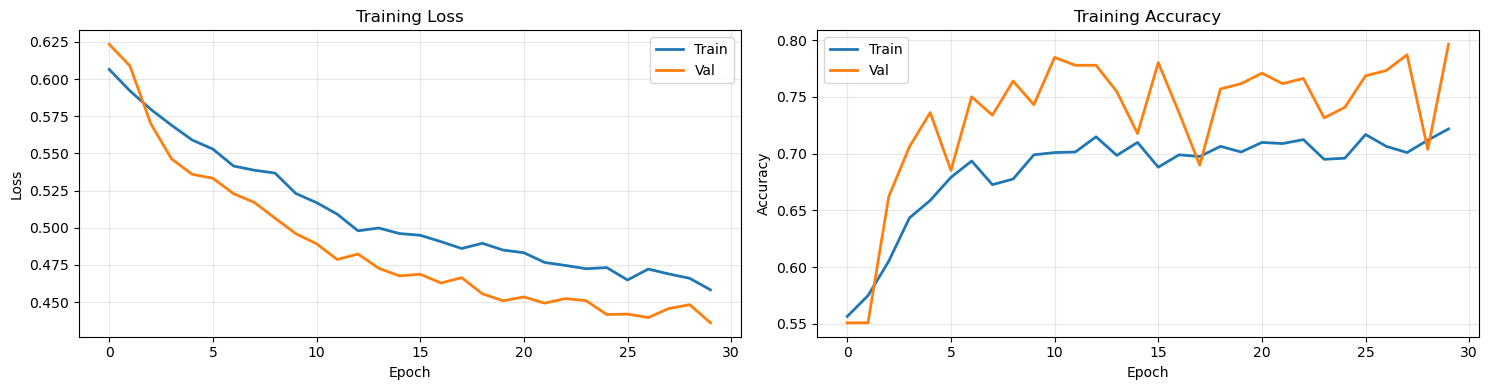

Optimal threshold: 0.46


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Loss
axes[0].plot(history["train_loss"], label="Train", linewidth=2)
axes[0].plot(history["val_loss"], label="Val", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history["train_acc"], label="Train", linewidth=2)
axes[1].plot(history["val_acc"], label="Val", linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)


plt.tight_layout()
plt.show()

print(f"Optimal threshold: {history['best_threshold']:.2f}")

## 5. Evaluation

In [11]:
# Load best model
from pathlib import Path

checkpoint = torch.load(Path("checkpoints_demo") / "best_model.pth", weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])

# Evaluate
metrics = evaluate_model(model, test_loader, threshold=history["best_threshold"])


TEST RESULTS (threshold=0.46)
  Accuracy:  0.8245
  F1-Score:  0.8492
  MCC:       0.6455
  Precision: 0.8075
  Recall:    0.8954

  Confusion Matrix:
    TP:  214  FP:   51
    FN:   25  TN:  143



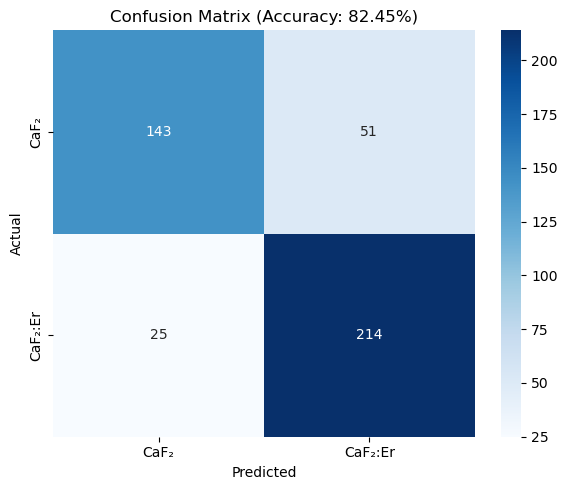

In [12]:
# Confusion matrix visualization
cm = metrics["confusion_matrix"]
cm_array = np.array([[cm["tn"], cm["fp"]], [cm["fn"], cm["tp"]]])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_array,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax,
    xticklabels=["CaF₂", "CaF₂:Er"],
    yticklabels=["CaF₂", "CaF₂:Er"],
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix (Accuracy: {metrics['accuracy'] * 100:.2f}%)")
plt.tight_layout()
plt.show()

## 6. Summary

In [13]:
print("=" * 50)
print("HQNN RESULTS SUMMARY")
print("=" * 50)
print("\nModel:")
print(f"  - Qubits: {model.n_qubits}")
print(f"  - Quantum layers: {model.n_layers}")
print(f"  - Total params: {sum(p.numel() for p in model.parameters())}")
print("\nPerformance:")
print(f"  - Accuracy: {metrics['accuracy'] * 100:.2f}%")
print(f"  - F1-Score: {metrics['f1']:.4f}")
print(f"  - MCC: {metrics['mcc']:.4f}")
print(f"  - Precision: {metrics['precision']:.4f}")
print(f"  - Recall: {metrics['recall']:.4f}")
print("=" * 50)

HQNN RESULTS SUMMARY

Model:
  - Qubits: 3
  - Quantum layers: 4
  - Total params: 105

Performance:
  - Accuracy: 82.45%
  - F1-Score: 0.8492
  - MCC: 0.6455
  - Precision: 0.8075
  - Recall: 0.8954
